In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sdplab.sdp import SDPDenseProblem
from sdplab.special.qot import generate_random_qot, solve_qot_dual, QOTConstraintOp
from sdplab.regularization import EntropyRegLog, SDPRegularized, QuadraticReg
from sdplab.solvers import run_optax_solver, run_torch_solver, run_jaxlib_solver
import spacecore as sc

sc.set_context('numpy', enable_checks=False, dtype=complex)

## Example of defining QOT problem
___

Feel free to define your own `cost_matrix` (should be of shape $(d^N, d^N)$), `marginals` (should be of shape $(N, d, d)$)

In [2]:
d = 5  # Size of marginal
N = 2  # Number of marginals
D = d ** N  # Total dimension

# Generate random cost matrix
seed = 10
rng = np.random.default_rng(seed)
cost_re_im = rng.normal(size=(2, D, D))
cost_matrix = cost_re_im[0, :, :] + 1j * cost_re_im[1, :, :]
cost_matrix = (cost_matrix + cost_matrix.T.conj()) * .5

# Define linear operator responsible for QOT constraints
qot_op = QOTConstraintOp(d=d, N=N)

# Use eigvals to get marginals
evals, evecs = np.linalg.eigh(cost_matrix)  # Compute eigenvalues and eigenvectors
proportions = (0., 1.)  # Coeffs for eigvec convex combination
Gamma = sum(p * np.outer(v, v.conj()) for p, v in zip(proportions, evecs.T))  # Convex combination of eigvals
Gamma = (Gamma + Gamma.T.conj()) * .5  # Symmetrize; got reference state
marginals = qot_op.apply(Gamma)  # Compute marginals using QOT constraint operator defined above

# Combine everything
qot = SDPDenseProblem(cost_matrix, qot_op, marginals)
primal_feasible = qot.primal_from_array(Gamma)

## Solve unregularized QOT

In [3]:
primal_sdp, dual_sdp = solve_qot_dual(qot, 'SCS', verbose=True)

(CVXPY) May 19 02:52:43 AM: Your problem has 50 variables, 625 constraints, and 0 parameters.
(CVXPY) May 19 02:52:43 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 19 02:52:43 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 19 02:52:43 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 19 02:52:43 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) May 19 02:52:43 AM: Compiling problem (target solver=SCS).
(CVXPY) May 19 02:52:43 AM: Reduction chain: Complex2Real -> FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) May 19 02:52:43 AM: Applying reduction Complex2Real
(CVXPY) May 19 02:52:43 AM: Applying reduction FlipObjective
(CVXPY) May 19 02:52:43 AM: Applying reduction Dcp2Cone
(CVXPY) May 19 02:52:43 AM: Applying reduction CvxAttr2Constr
(CVXPY) May 19 02:52:43 AM: Ap

                                     CVXPY                                     
                                     v1.8.0                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 50, constraints m: 1275
cones: 	  s: psd vars: 1275, ssize: 1
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05,

(CVXPY) May 19 02:52:44 AM: Problem status: optimal
(CVXPY) May 19 02:52:44 AM: Optimal value: -7.607e+00
(CVXPY) May 19 02:52:44 AM: Compilation took 2.940e-02 seconds
(CVXPY) May 19 02:52:44 AM: Solver (including time spent in interface) took 2.678e-01 seconds


   250| 5.21e-04  6.21e-05  1.74e-04  7.61e+00  1.57e-03  2.14e-01 
   325| 1.17e-05  6.45e-07  9.46e-06  7.61e+00  1.57e-03  2.67e-01 
------------------------------------------------------------------
status:  solved
timings: total: 2.67e-01s = setup: 2.36e-03s + solve: 2.65e-01s
	 lin-sys: 4.99e-03s, cones: 2.54e-01s, accel: 3.29e-03s
------------------------------------------------------------------
objective = 7.606748
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


## Solve Entropy Regularized QOT

In [4]:
import jax
import optax
jax.config.update("jax_enable_x64", True)

jax_ctx = sc.Context(sc.JaxOps(), dtype=complex, enable_checks=False)

qot_jax = qot.convert(jax_ctx)
primal_feasible_jax = primal_feasible.convert(jax_ctx)

eps = 1e-9
Reg = EntropyRegLog(eps, ctx=jax_ctx)
sdp_reg = SDPRegularized(qot_jax, Reg)
opt = optax.lbfgs()
init_dual = qot_jax.A_apply(primal_feasible_jax)
max_iter = 10_000

/Users/pavlopelikh/Documents/Dev/SDPLab/.venv/lib/python3.13/site-packages/spacecore/_contextual/contextual.py:460: UserWarning: Converting from Context(ops=NumpyOps, dtype=dtype('complex128'), enable_checks=False) to Context(ops=JaxOps, dtype=dtype('complex128'), enable_checks=False).
  warn(


In [5]:
jaxlib_info_entropy = run_jaxlib_solver(
    sdp_reg,
    init_dual=init_dual,
    learning_rate=1e-2,
    max_iter=max_iter,
    tol=1e-10,
    verbose=True,
)


[iter 0] dual_obj=-8.622120e+00 grad_norm=9.473382e-01
[iter 50] dual_obj=-8.186453e+00 grad_norm=9.160793e-01
[iter 100] dual_obj=-7.825672e+00 grad_norm=6.031970e-01
[iter 150] dual_obj=-7.777233e+00 grad_norm=2.763279e-01
[iter 200] dual_obj=-7.764336e+00 grad_norm=2.655466e-01
[iter 250] dual_obj=-7.751541e+00 grad_norm=2.534844e-01
[iter 300] dual_obj=-7.741647e+00 grad_norm=2.449871e-01
[iter 350] dual_obj=-7.732312e+00 grad_norm=2.343837e-01
[iter 400] dual_obj=-7.723736e+00 grad_norm=8.760298e-01
[iter 450] dual_obj=-7.715779e+00 grad_norm=2.151850e-01
[iter 500] dual_obj=-7.708318e+00 grad_norm=2.047518e-01
[iter 550] dual_obj=-7.702973e+00 grad_norm=1.999205e-01
[iter 600] dual_obj=-7.697881e+00 grad_norm=1.957636e-01
[iter 650] dual_obj=-7.691903e+00 grad_norm=1.833627e-01
[iter 700] dual_obj=-7.686827e+00 grad_norm=1.759143e-01
[iter 750] dual_obj=-7.683057e+00 grad_norm=8.959544e-01
[iter 800] dual_obj=-7.678756e+00 grad_norm=1.637264e-01
[iter 850] dual_obj=-7.675629e+00 

In [6]:
opt_info = run_optax_solver(sdp_reg, init_dual, opt, max_iter, tol=1e-10, verbose=True)

[iter 0] dual_obj=-8.622120e+00 grad_norm=9.473382e-01
[iter 50] dual_obj=-7.621633e+00 grad_norm=1.660711e-01
[iter 100] dual_obj=-7.614054e+00 grad_norm=2.110929e-01
[iter 150] dual_obj=-7.611080e+00 grad_norm=2.195254e-01
[iter 200] dual_obj=-7.611065e+00 grad_norm=1.455685e-01
[iter 250] dual_obj=-7.610245e+00 grad_norm=2.317697e-01
[iter 300] dual_obj=-7.609536e+00 grad_norm=1.695473e-01
[iter 350] dual_obj=-7.609534e+00 grad_norm=2.061245e-01
[iter 400] dual_obj=-7.608971e+00 grad_norm=1.854569e-01
[iter 450] dual_obj=-7.608846e+00 grad_norm=4.029859e-01
[iter 500] dual_obj=-7.608846e+00 grad_norm=3.599262e-01
[iter 550] dual_obj=-7.608707e+00 grad_norm=5.945351e-02
[iter 600] dual_obj=-7.608705e+00 grad_norm=1.151419e-01
[iter 650] dual_obj=-7.608539e+00 grad_norm=9.089601e-02
[iter 700] dual_obj=-7.608539e+00 grad_norm=1.397687e-02
[iter 750] dual_obj=-7.608365e+00 grad_norm=1.001764e-01
[iter 800] dual_obj=-7.608365e+00 grad_norm=5.540328e-02
[iter 850] dual_obj=-7.608357e+00 

Text(0.5, 1.0, 'Gradient norm')

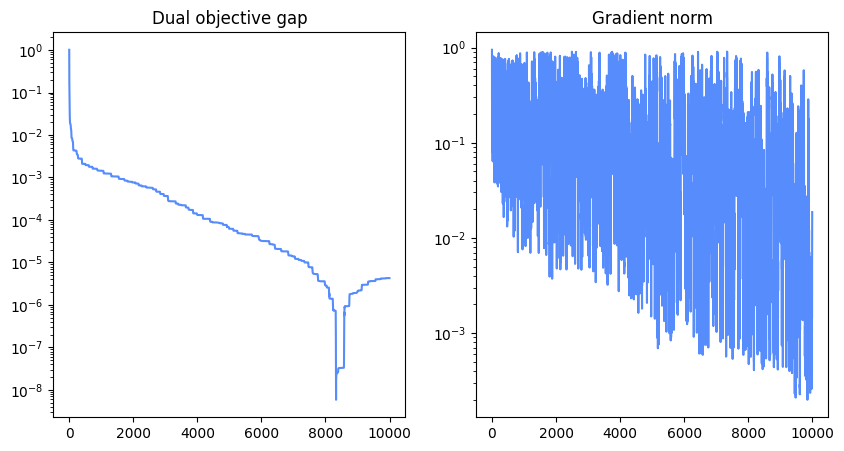

In [7]:
opt_obj = qot.dual_objective(dual_sdp)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].semilogy(qot_jax.ops.abs(opt_info.dual_obj - opt_obj))
axs[0].set_title('Dual objective gap')
axs[1].semilogy(opt_info.grad_norm)
axs[1].set_title('Gradient norm')

In [8]:
from sdplab.solvers.pdhg import run_pdhg_solver

In [9]:
from spacecore import TorchOps, Context, JaxOps, NumpyOps
ctx = Context(ops=JaxOps(), dtype=complex, enable_checks=False)

l2_reg = QuadraticReg(1e-4, ctx=ctx)
qot_l2 = SDPRegularized(qot.convert(ctx), l2_reg)

In [10]:
pdhg_conv_info = run_pdhg_solver(qot_l2, verbose=True, tau=1e-1, sigma=1e-1, max_iter=20000, jit=True, tol=1e-20, log_every=50)

/Users/pavlopelikh/Documents/Dev/SDPLab/.venv/lib/python3.13/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=float64 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(
/Users/pavlopelikh/Documents/Dev/SDPLab/.venv/lib/python3.13/site-packages/jax/_src/ops/scatter.py:148: ComplexWarning: Casting complex values to real discards the imaginary part
  return lax._convert_element_type(out, dtype, weak_type)


[iter 0] primal_obj=-3.069531e+01 resid=inf
[iter 50] primal_obj=0.000000e+00 resid=inf
[iter 100] primal_obj=-8.200597e+00 resid=1.014090e+00
[iter 150] primal_obj=-8.222576e+00 resid=3.725942e-01
[iter 200] primal_obj=-8.070167e+00 resid=2.258666e-01
[iter 250] primal_obj=-7.579890e+00 resid=2.258666e-01
[iter 300] primal_obj=-7.078792e+00 resid=1.557540e-01
[iter 350] primal_obj=-6.937584e+00 resid=8.506061e-02
[iter 400] primal_obj=-7.111511e+00 resid=5.526813e-02
[iter 450] primal_obj=-7.325491e+00 resid=4.379814e-02
[iter 500] primal_obj=-7.422882e+00 resid=4.379814e-02
[iter 550] primal_obj=-7.427424e+00 resid=3.701252e-02
[iter 600] primal_obj=-7.670566e+00 resid=3.131081e-02
[iter 650] primal_obj=-7.646642e+00 resid=2.051462e-02
[iter 700] primal_obj=-7.601494e+00 resid=2.051462e-02
[iter 750] primal_obj=-7.631986e+00 resid=1.681882e-02
[iter 800] primal_obj=-7.612311e+00 resid=1.502244e-02
[iter 850] primal_obj=-7.617831e+00 resid=1.304607e-02
[iter 900] primal_obj=-7.632080e

Text(0.5, 1.0, 'Gradient norm')

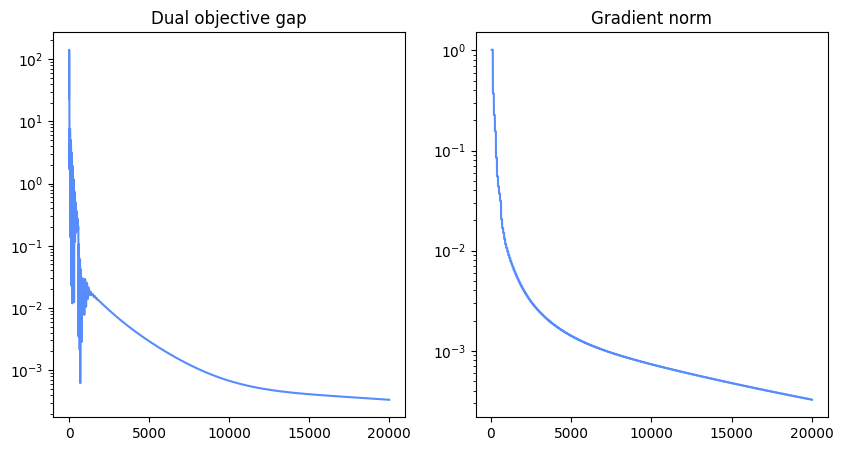

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].semilogy(qot_l2.sdp.ops.abs(pdhg_conv_info.primal_obj - opt_obj))
axs[0].set_title('Dual objective gap')
axs[1].semilogy(pdhg_conv_info.grad_norm)
axs[1].set_title('Gradient norm')

## Solver entry point examples

The cells below reuse the `qot` problem built above and show the current public entry points for each solver backend. The iteration counts are intentionally small for notebook checks; increase them for production runs.


In [12]:
from sdplab.solvers import (
    run_jaxlib_solver,
    run_optax_solver,
    run_torch_solver,
)
from sdplab.solvers.pdhg import run_pdhg_solver
from sdplab.regularization import QuadraticReg, SDPRegularized
import jax
import optax
import torch

jax.config.update("jax_enable_x64", True)

example_eps = 1e-4
example_learning_rate = 1e-2
example_max_iter = 250
example_tol = 1e-8
example_log_every = 50


### CVXPY reference solver


In [13]:
from sdplab.special.qot import solve_qot_dual

cvxpy_primal, cvxpy_dual = solve_qot_dual(
    qot,
    solver="SCS",
    verbose=False,
)


### JAX solvers


In [14]:
jax_ctx = sc.Context(sc.JaxOps(), dtype=complex, enable_checks=False)
qot_jax_l2 = SDPRegularized(
    qot.convert(jax_ctx),
    QuadraticReg(example_eps, ctx=jax_ctx),
)

jaxlib_info = run_jaxlib_solver(
    qot_jax_l2,
    learning_rate=example_learning_rate,
    max_iter=example_max_iter,
    tol=example_tol,
    verbose=True,
    log_every=example_log_every,
)

optax_info = run_optax_solver(
    qot_jax_l2,
    opt=optax.adam(example_learning_rate),
    max_iter=example_max_iter,
    tol=example_tol,
    verbose=True,
    log_every=example_log_every,
)


[iter 0] dual_obj=-1.522142e+06 grad_norm=3.417207e+05
[iter 50] dual_obj=-2.528931e+03 grad_norm=1.009057e+00
[iter 100] dual_obj=-2.528422e+03 grad_norm=1.009057e+00
[iter 150] dual_obj=-2.527913e+03 grad_norm=1.009057e+00
[iter 200] dual_obj=-2.527404e+03 grad_norm=1.009057e+00
[iter 0] dual_obj=-1.522142e+06 grad_norm=3.417207e+05
[iter 50] dual_obj=-9.638953e+05 grad_norm=2.492303e+05
[iter 100] dual_obj=-6.559225e+05 grad_norm=1.931875e+05
[iter 150] dual_obj=-4.514858e+05 grad_norm=1.518821e+05
[iter 200] dual_obj=-3.138626e+05 grad_norm=1.190382e+05


### PyTorch solver


In [15]:
torch_ctx = sc.Context(sc.TorchOps(), dtype=complex, enable_checks=False)
qot_torch_l2 = SDPRegularized(
    qot.convert(torch_ctx),
    QuadraticReg(example_eps, ctx=torch_ctx),
)

torch_adam_info = run_torch_solver(
    qot_torch_l2,
    opt=torch.optim.Adam,
    learning_rate=example_learning_rate,
    max_iter=example_max_iter,
    tol=example_tol,
    verbose=True,
    log_every=example_log_every,
)

torch_lbfgs_info = run_torch_solver(
    qot_torch_l2,
    opt=torch.optim.LBFGS,
    learning_rate=1.0,
    max_iter=25,
    tol=example_tol,
    verbose=True,
    log_every=5,
    line_search_fn="strong_wolfe",
)


/Users/pavlopelikh/Documents/Dev/SDPLab/.venv/lib/python3.13/site-packages/spacecore/_contextual/contextual.py:460: UserWarning: Converting from Context(ops=NumpyOps, dtype=dtype('complex128'), enable_checks=False) to Context(ops=TorchOps, dtype=torch.complex128, enable_checks=False).
  warn(


[iter 0] dual_obj=-1.522142e+06 grad_norm=3.417207e+05
[iter 50] dual_obj=-9.638953e+05 grad_norm=2.492303e+05
[iter 100] dual_obj=-6.559225e+05 grad_norm=1.931875e+05
[iter 150] dual_obj=-4.514858e+05 grad_norm=1.518821e+05
[iter 200] dual_obj=-3.138626e+05 grad_norm=1.190382e+05
[iter 0] dual_obj=-8.299106e+00 grad_norm=1.577343e+01
[iter 5] dual_obj=-7.710568e+00 grad_norm=2.111461e+00
[iter 10] dual_obj=-7.651867e+00 grad_norm=1.523414e+00
[iter 15] dual_obj=-7.617673e+00 grad_norm=1.448076e-01
[iter 20] dual_obj=-7.611000e+00 grad_norm=2.417623e-01


### PDHG solver


In [16]:
pdhg_info = run_pdhg_solver(
    qot_jax_l2,
    tau=1e-1,
    sigma=1e-1,
    max_iter=example_max_iter,
    tol=example_tol,
    jit=True,
    verbose=True,
    log_every=example_log_every,
)


[iter 0] primal_obj=-3.069531e+01 resid=inf
[iter 50] primal_obj=0.000000e+00 resid=inf
[iter 100] primal_obj=-8.200597e+00 resid=1.014090e+00
[iter 150] primal_obj=-8.222576e+00 resid=3.725942e-01
[iter 200] primal_obj=-8.070167e+00 resid=2.258666e-01


/Users/pavlopelikh/Documents/Dev/SDPLab/.venv/lib/python3.13/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=float64 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(
/Users/pavlopelikh/Documents/Dev/SDPLab/.venv/lib/python3.13/site-packages/jax/_src/ops/scatter.py:148: ComplexWarning: Casting complex values to real discards the imaginary part
  return lax._convert_element_type(out, dtype, weak_type)


### Collected results


In [17]:
solver_examples = {
    "cvxpy": (cvxpy_primal, cvxpy_dual),
    "jaxlib": jaxlib_info,
    "optax": optax_info,
    "torch_adam": torch_adam_info,
    "torch_lbfgs": torch_lbfgs_info,
    "pdhg": pdhg_info,
}

{
    name: type(result).__name__
    for name, result in solver_examples.items()
}


{'cvxpy': 'tuple',
 'jaxlib': 'ConvergenceInfo',
 'optax': 'ConvergenceInfo',
 'torch_adam': 'ConvergenceInfo',
 'torch_lbfgs': 'ConvergenceInfo',
 'pdhg': 'ConvergenceInfo'}